In [5]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import yaml
import os

In [2]:
def stitch_images(full_img, cropped_img, inner_bound, outer_bound, blend_width=5):
    """
    Stitch two images together by replacing an annular region in the full image with the
    corresponding region from the cropped image, using a blending ring at the boundaries.
    
    Parameters:
      full_img (ndarray): 2D numpy array for the full-size image.
      cropped_img (ndarray): 2D numpy array for the cropped image.
      inner_bound (float): Inner radius of the annular region to replace.
      outer_bound (float): Outer radius of the annular region to replace.
      blend_width (float): Width (in pixels) of the blending region at both inner and outer edges.
                           Default is 5 pixels.
    
    Returns:
      stitched (ndarray): The stitched image as a 2D numpy array.
    """
    
    # Create a copy of the full image for the output
    stitched = full_img.copy()
    
    # Determine the center of the image
    ny, nx = full_img.shape
    cy, cx = ny / 2, nx / 2
    
    # Create coordinate grid (each pixel's distance from the center)
    y, x = np.indices(full_img.shape)
    r = np.sqrt((y - cy)**2 + (x - cx)**2)
    
    # Region definitions:
    # 1. Inner blend: pixels between inner_bound and (inner_bound + blend_width)
    inner_blend_mask = (r >= inner_bound) & (r < inner_bound + blend_width)
    # 2. Full replacement: pixels well inside the annulus (no blending)
    full_replace_mask = (r >= inner_bound + blend_width) & (r <= outer_bound - blend_width)
    # 3. Outer blend: pixels between (outer_bound - blend_width) and outer_bound
    outer_blend_mask = (r > outer_bound - blend_width) & (r <= outer_bound)
    
    # Replace the full replacement region entirely with the cropped image
    stitched[full_replace_mask] = cropped_img[full_replace_mask]
    
    # Blend inner edge:
    # Weight goes from 0 (at r = inner_bound, use full_img) to 1 (at r = inner_bound+blend_width, use cropped_img)
    inner_weights = (r[inner_blend_mask] - inner_bound) / blend_width
    stitched[inner_blend_mask] = (1 - inner_weights) * full_img[inner_blend_mask] + inner_weights * cropped_img[inner_blend_mask]
    
    # Blend outer edge:
    # Weight goes from 1 (at r = outer_bound - blend_width, use cropped_img) to 0 (at r = outer_bound, use full_img)
    outer_weights = (outer_bound - r[outer_blend_mask]) / blend_width
    stitched[outer_blend_mask] = outer_weights * cropped_img[outer_blend_mask] + (1 - outer_weights) * full_img[outer_blend_mask]
    
    return stitched

In [10]:
basedir = f"{os.environ["HOME"]}/projects/debrisdisk_freeform_fit_and_plot"
str_yaml = f"{basedir}/initialization_files/HR4796_r_camsci1_20230312_13.yaml"

In [11]:
str_yaml_prefix = str_yaml.split("/")[-1]
save_to_dir = str_yaml_prefix.split(".")[0]

print("Read " + str_yaml + " parameter file")
# open the parameter file
yaml_path_file = os.path.join(os.getcwd(), str_yaml)
with open(yaml_path_file, 'r') as yaml_file:
    params_mcmc_yaml = yaml.safe_load(yaml_file)
# Grab the info from the yaml file
FILE_PREFIX = params_mcmc_yaml['FILE_PREFIX']
# KLIPDIR = os.path.join(basedir, params_mcmc_yaml['BAND_DIR'],
#                     'klip_fm_files')
RESULTS_DIR = os.path.join(basedir, params_mcmc_yaml['BAND_DIR'],
                    'results_freeform')
# load DISTANCE_STAR & PIXSCALE_INS and make them global
DISTANCE_STAR = params_mcmc_yaml['DISTANCE_STAR']
PIXSCALE_INS = params_mcmc_yaml['PIXSCALE_INS']
ALIGNED_CENTER = params_mcmc_yaml['ALIGNED_CENTER']

Read /Users/jkueny/projects/debrisdisk_freeform_fit_and_plot/initialization_files/HR4796_r_camsci1_20230312_13.yaml parameter file


#### Load the full and small freeform result images

In [12]:
full_freeform = fits.getdata(f"{basedir}/HR4796_r_camsci1_20230312_13/freeform_run_50kiter_106parangspan.fits")
crop_freeform = fits.getdata(f"{basedir}/HR4796_r_camsci1_20230312_13/freeform_run_small_10kiter.fits")

In [14]:
stitched_image = stitch_images(full_freeform, crop_freeform, inner_bound=16, outer_bound=32, blend_width=3)

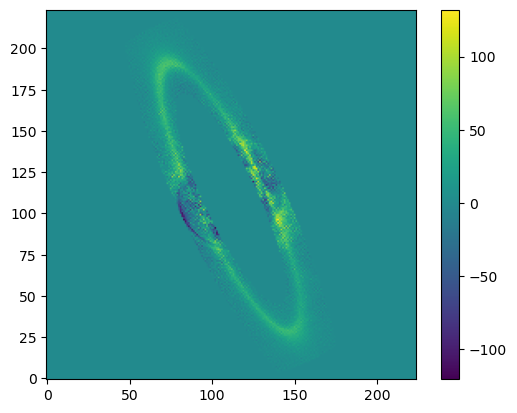

In [15]:
plt.imshow(stitched_image, origin="lower")
plt.colorbar()